In [1]:
!pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   - -------------------------------------- 1.0/39.5 MB 10.1 MB/s eta 0:00:04
   --- ------------------------------------ 3.7/39.5 MB 11.5 MB/s eta 0:00:04
   ----- ---------------------------------- 5.0/39.5 MB 10.1 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/39.5 MB 8.8 MB/s eta 0:00:04
   ------ --------------------------------- 6.8/39.5 MB 7.5 MB/s eta 0:00:05
   ------- -------------------------------- 7.9/39.5 MB 6.9 MB/s eta 0:00:05
   --------- ------------------------------ 8.9/39.5 MB 6.5 MB/s eta 0:00:05
   --------- ------------------------------ 9.7/39.5 MB 6.4 MB/s eta 0:00:05
   ---------- ----------------------------- 10.2/39.5 MB 6.0 MB/s eta 0:00:05
   ---------- ----------------------------- 10.7/39.5 MB 5.4 MB/s eta 0:00:06
   ----------- ---------------------------- 11.0/39.5 MB 5.1 MB/s eta 0:00:06
   ----------- ---------------------------- 11.3/39.5 MB 4.8 MB/s eta 0:00:06

In [13]:
import cv2
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Path to the image directory and CSV file
image_dir = 'C:/Users/ASUA/OneDrive/Desktop/Images'
csv_file = 'C:/Users/ASUA/OneDrive/Desktop/Final Project/Dataset1.csv'

# Load the CSV file containing the water quality data
data = pd.read_csv(csv_file, encoding='utf-8') 
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(data.head())
print(data.shape)
print(data.describe())

# Function to extract color histogram from an image
def extract_color_histogram(image, bins=(8, 8, 8)):
    # Convert the image to the HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Compute the histogram and normalize it
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

# Initialize lists to store features and labels
features = []
labels = []

# Loop through the dataset and extract features
for index, row in data.iterrows():
    image_path = os.path.join(image_dir, row['Image Path'])
    image = cv2.imread(image_path)
    
    if image is not None:
        hist = extract_color_histogram(image)
        features.append(hist)
        labels.append(row['Prawn Suitability'])

# Convert lists to NumPy arrays
features = np.array(features)
labels = np.array(labels)

# Encode labels (if necessary)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)
features

         Image Path  Ph(6.5-8.5)  Turbidity(30-80NTU)  DO(5 - 8 mg/L)  \
0  ..\Images\31.jpg         7.56                   58            8.41   
1  ..\Images\70.jpg        12.50                  225            1.70   
2  ..\Images\65.jpg         3.80                  175            0.70   
3  ..\Images\50.jpg        10.10                  215            1.80   
4  ..\Images\45.jpg         4.20                  150            0.80   

   Temperature(28–31°C) Prawn Suitability  
0                 30.76          Suitable  
1                 45.00        Unsuitable  
2                 36.50        Unsuitable  
3                 18.50          Suitable  
4                 38.00        Unsuitable  
(102, 6)
       Ph(6.5-8.5)  Turbidity(30-80NTU)  DO(5 - 8 mg/L)  Temperature(28–31°C)
count   102.000000           102.000000      102.000000            102.000000
mean      6.421863           106.088235        6.805098             34.847745
std       2.249708            66.802962        7.96298

array([[1.5156744e-06, 0.0000000e+00, 1.0609720e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 4.4118398e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.2656973e-06, 1.5188367e-05, 1.7719762e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [0.0000000e+00, 0.0000000e+00, 6.0250113e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [15]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

# Load the CSV file with water quality parameters
data = pd.read_csv(csv_file)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Separate features (image filenames) and target variables (water quality + suitability)
target_cols = ['Ph(6.5-8.5)', 'Turbidity(30-80NTU)', 'DO(5 - 8 mg/L)', 'Temperature(28–31°C)', 'Prawn Suitability']
image_filenames = data['Image Path']
targets = data[target_cols]

# Encode categorical targets (Prawn Suitability)
targets['Prawn Suitability'] = le.fit_transform(targets['Prawn Suitability'])

# Prepare feature extraction and data loading (as in the previous code)
features = []
for index, row in data.iterrows():
    image_path = os.path.join(image_dir, row['Image Path'])
    image = cv2.imread(image_path)
    
    if image is not None:
        hist = extract_color_histogram(image)
        features.append(hist)

# Convert features and targets to NumPy arrays
features = np.array(features)
targets = targets.to_numpy()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.3, random_state=42)


# Separate continuous (water quality) and categorical (suitability) targets
water_quality_targets = y_train[:, :-1]  # All columns except the last (continuous targets)
suitability_target = y_train[:, -1]      # Last column (categorical target)

# Train a multi-output regressor for water quality parameters
multi_output_regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
multi_output_regressor.fit(X_train, water_quality_targets)

dt_regressor = MultiOutputRegressor(DecisionTreeRegressor(random_state=42))
dt_regressor.fit(X_train, water_quality_targets)

knn_regressor = KNeighborsRegressor(n_neighbors=5)  
knn_regressor.fit(X_train, water_quality_targets)

# Train a classifier for prawn suitability
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, suitability_target)

#Train a Gradient Boosting Classifier for suitability
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, suitability_target)

knn_classifier = KNeighborsClassifier(n_neighbors=5)  # Example with 5 neighbors
knn_classifier.fit(X_train, suitability_target)

# Make predictions on the test set
water_quality_pred = multi_output_regressor.predict(X_test)
suitability_pred = clf.predict(X_test)
dt_pred = dt_classifier.predict(X_test)
knn_pred = knn_classifier.predict(X_test)

# Evaluate predictions (you can calculate accuracy for suitability and RMSE for water quality)
suitability_accuracy = accuracy_score(y_test[:, -1], suitability_pred)*100
print(f"Suitability Prediction Accuracy for RandomForest : {suitability_accuracy:.2f}%")
print("Suitability prediction Accuracy for Decision Tree regressor:", accuracy_score(y_test[:, -1], dt_pred)*100)
print("Suitability prediction Accuracy for Knn regressor:", accuracy_score(y_test[:, -1], knn_pred)*100)

print("-----------------------------------------------------------------------------------------------------")
from sklearn.metrics import mean_squared_error
import math

# Calculate RMSE for each water quality parameter
ph_rmse1 = math.sqrt(mean_squared_error(y_test[:, 0], water_quality_pred[:, 0])/100)
turbidity_rmse1 = math.sqrt(mean_squared_error(y_test[:, 1], water_quality_pred[:, 1])/100)
do_rmse1 = math.sqrt(mean_squared_error(y_test[:, 2], water_quality_pred[:, 2])/100)
temperature_rmse1 = math.sqrt(mean_squared_error(y_test[:, 3], water_quality_pred[:, 3])/100)

# Print individual RMSE values
print("RMSE for RadamForestRegressor")
print(f"pH Prediction RMSE: {ph_rmse1:.2f}")
print(f"Turbidity Prediction RMSE: {turbidity_rmse1:.2f}")
print(f"DO Prediction RMSE: {do_rmse1:.2f}")
print(f"Temperature Prediction RMSE: {temperature_rmse1:.2f}")

# Overall RMSE for all water quality parameters
overall_rmse = math.sqrt(mean_squared_error(y_test[:, :-1], water_quality_pred)/100)
print(f"Overall Water Quality Prediction RMSE: {overall_rmse:.2f}")

print("------------------------------------------------------------------------------")
decision_pred = dt_regressor.predict(X_test)

# Calculate RMSE for each water quality parameter
ph_rmse2 = math.sqrt(mean_squared_error(y_test[:, 0], decision_pred[:, 0])/100)
turbidity_rmse2 = math.sqrt(mean_squared_error(y_test[:, 1], decision_pred[:, 1])/100)
do_rmse2 = math.sqrt(mean_squared_error(y_test[:, 2], decision_pred[:, 2])/100)
temperature_rmse2 = math.sqrt(mean_squared_error(y_test[:, 3], decision_pred[:, 3])/100)

# Print individual RMSE values
print("RMSE for DecisionTreeRegression")
print(f"pH Prediction RMSE: {ph_rmse2:.2f}")
print(f"Turbidity Prediction RMSE: {turbidity_rmse2:.2f}")
print(f"DO Prediction RMSE: {do_rmse2:.2f}")
print(f"Temperature Prediction RMSE: {temperature_rmse2:.2f}")

# Overall RMSE for all water quality parameters
overall_rmse2 = math.sqrt(mean_squared_error(y_test[:, :-1], decision_pred)/100)
print(f"Overall Water Quality Prediction RMSE: {overall_rmse2:.2f}")

print("------------------------------------------------------------------------------")
kneighbor_pred = knn_regressor.predict(X_test)

# Calculate RMSE for each water quality parameter
ph_rmse3 = math.sqrt(mean_squared_error(y_test[:, 0], kneighbor_pred[:, 0])/100)
turbidity_rmse3 = math.sqrt(mean_squared_error(y_test[:, 1], kneighbor_pred[:, 1])/100)
do_rmse3 = math.sqrt(mean_squared_error(y_test[:, 2], kneighbor_pred[:, 2])/100)
temperature_rmse3 = math.sqrt(mean_squared_error(y_test[:, 3], kneighbor_pred[:, 3])/100)

# Print individual RMSE values
print("RMSE for KNNRegression")
print(f"pH Prediction RMSE: {ph_rmse3:.2f}")
print(f"Turbidity Prediction RMSE: {turbidity_rmse3:.2f}")
print(f"DO Prediction RMSE: {do_rmse3:.2f}")
print(f"Temperature Prediction RMSE: {temperature_rmse3:.2f}")

# Overall RMSE for all water quality parameters
overall_rmse3 = math.sqrt(mean_squared_error(y_test[:, :-1], kneighbor_pred)/100)
print(f"Overall Water Quality Prediction RMSE: {overall_rmse3:.2f}")



C:\Users\ASUA\AppData\Local\Temp\ipykernel_11036\16084525.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  targets['Prawn Suitability'] = le.fit_transform(targets['Prawn Suitability'])


Suitability Prediction Accuracy for RandomForest : 87.10%
Suitability prediction Accuracy for Decision Tree regressor: 51.61290322580645
Suitability prediction Accuracy for Knn regressor: 64.51612903225806
-----------------------------------------------------------------------------------------------------
RMSE for RadamForestRegressor
pH Prediction RMSE: 0.26
Turbidity Prediction RMSE: 6.89
DO Prediction RMSE: 0.65
Temperature Prediction RMSE: 5.49
Overall Water Quality Prediction RMSE: 4.42
------------------------------------------------------------------------------
RMSE for DecisionTreeRegression
pH Prediction RMSE: 0.27
Turbidity Prediction RMSE: 8.95
DO Prediction RMSE: 0.83
Temperature Prediction RMSE: 5.43
Overall Water Quality Prediction RMSE: 5.25
------------------------------------------------------------------------------
RMSE for KNNRegression
pH Prediction RMSE: 0.28
Turbidity Prediction RMSE: 6.86
DO Prediction RMSE: 0.71
Temperature Prediction RMSE: 5.55
Overall Water

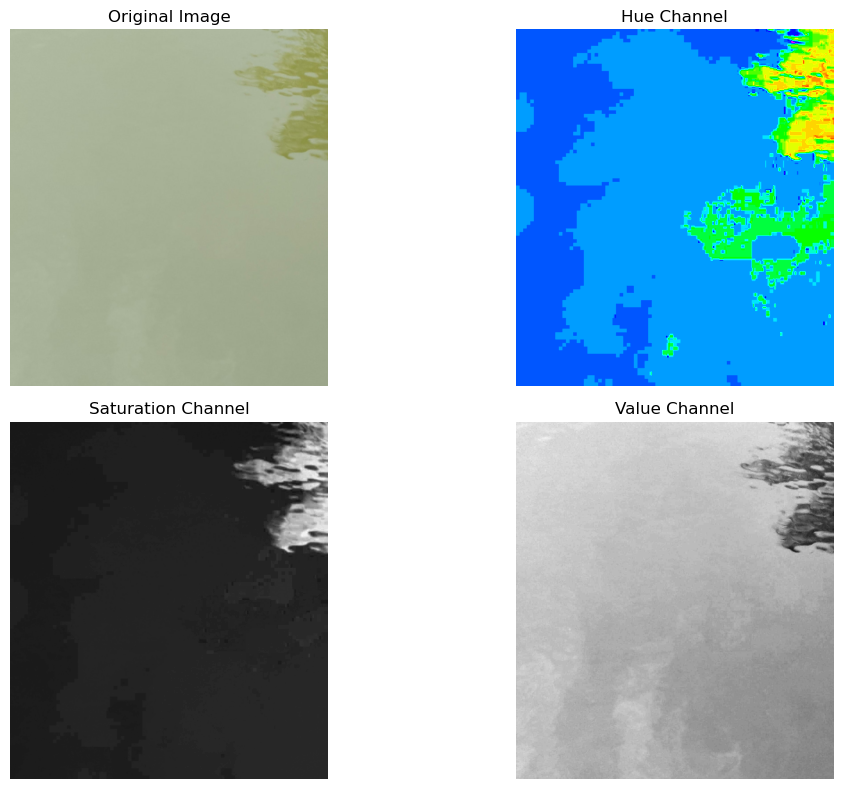

Predicted Water Quality Parameters:
PH: 7.07
Turbidity (NTU): 95.83
Dissolved Oxygen (mg/L): 6.50
Temperature (C): 30.99

Predicted Prawn Suitability: Suitable


In [17]:
import cv2
import numpy as np
import os

# Path to the new image
new_image_path = r'C:/Users/ASUA/OneDrive/Desktop/Images/2.jpeg'

# Load and preprocess the new image
new_image = cv2.imread(new_image_path)

if new_image is not None:
    # Convert the image to HSV format
    hsv_image = cv2.cvtColor(new_image, cv2.COLOR_BGR2HSV)

    # Split the HSV channels
    h, s, v = cv2.split(hsv_image)

    # Display the original image and HSV channels
    plt.figure(figsize=(12, 8))
    
    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    
    # Hue channel
    plt.subplot(2, 2, 2)
    plt.imshow(h, cmap='hsv')
    plt.title("Hue Channel")
    plt.axis("off")
    
    # Saturation channel
    plt.subplot(2, 2, 3)
    plt.imshow(s, cmap='gray')
    plt.title("Saturation Channel")
    plt.axis("off")
    
    # Value channel
    plt.subplot(2, 2, 4)
    plt.imshow(v, cmap='gray')
    plt.title("Value Channel")
    plt.axis("off")
    
    # Show the plot
    plt.tight_layout()
    plt.show()

    # Extract features (color histogram) from the new image
    new_image_hist = extract_color_histogram(new_image)
    new_image_hist = new_image_hist.reshape(1, -1)  # Reshape for model input

    # Predict water quality parameters using the trained regressor
    water_quality_pred = multi_output_regressor.predict(new_image_hist)
    
    # Predict suitability
    suitability_pred = clf.predict(new_image_hist)

    # Ensure prediction is an integer
    suitability_pred = suitability_pred.astype(int)

    # Decode the suitability label
    suitability_label = le.inverse_transform(suitability_pred)

    # Output the predictions
    print("Predicted Water Quality Parameters:")
    print(f"PH: {water_quality_pred[0][0]:.2f}")
    print(f"Turbidity (NTU): {water_quality_pred[0][1]:.2f}")
    print(f"Dissolved Oxygen (mg/L): {water_quality_pred[0][2]:.2f}")
    print(f"Temperature (C): {water_quality_pred[0][3]:.2f}")

    print(f"\nPredicted Prawn Suitability: {suitability_label[0]}")
else:
    print(f"Error: Could not load image from {new_image_path}")


In [39]:
!pip install gradio

   ---------------------------------------- 0.0/62.2 MB ? eta -:--:--
   -- ------------------------------------- 3.7/62.2 MB 19.8 MB/s eta 0:00:03
   --- ------------------------------------ 4.7/62.2 MB 11.0 MB/s eta 0:00:06
   --- ------------------------------------ 5.8/62.2 MB 9.3 MB/s eta 0:00:07
   ---- ----------------------------------- 6.8/62.2 MB 8.1 MB/s eta 0:00:07
   ---- ----------------------------------- 7.1/62.2 MB 6.9 MB/s eta 0:00:08
   ---- ----------------------------------- 7.6/62.2 MB 6.0 MB/s eta 0:00:10
   ----- ---------------------------------- 7.9/62.2 MB 5.7 MB/s eta 0:00:10
   ----- ---------------------------------- 8.7/62.2 MB 5.2 MB/s eta 0:00:11
   ------ --------------------------------- 9.4/62.2 MB 5.0 MB/s eta 0:00:11
   ------ --------------------------------- 10.5/62.2 MB 5.0 MB/s eta 0:00:11
   ------- -------------------------------- 11.5/62.2 MB 5.0 MB/s eta 0:00:11
   -------- ------------------------------- 13.1/62.2 MB 5.2 MB/s eta 0:00:10
 

In [19]:
import cv2
import numpy as np
import gradio as gr
from sklearn.preprocessing import LabelEncoder

# Load trained models (Ensure these are pre-trained and available)
# multi_output_regressor = ... (Your trained model for water quality)
# clf = ... (Your trained classification model)
# le = ... (Label Encoder for suitability labels)

def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

def predict_water_quality(image):
    # Convert to OpenCV format
    image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    # Extract color histogram features
    image_hist = extract_color_histogram(image)
    image_hist = image_hist.reshape(1, -1)

    # Predict water quality parameters
    water_quality_pred = multi_output_regressor.predict(image_hist)

    # Predict suitability
    suitability_pred = clf.predict(image_hist)
    suitability_pred = suitability_pred.astype(int)

    # Decode suitability label
    suitability_label = le.inverse_transform(suitability_pred)[0]

    # Create result dictionary
    results = {
        "PH": f"{water_quality_pred[0][0]:.2f}",
        "Turbidity (NTU)": f"{water_quality_pred[0][1]:.2f}",
        "Dissolved Oxygen (mg/L)": f"{water_quality_pred[0][2]:.2f}",
        "Temperature (C)": f"{water_quality_pred[0][3]:.2f}",
        "Prawn Suitability": suitability_label
    }

    return results

# Gradio Interface
interface = gr.Interface(
    fn=predict_water_quality,
    inputs=gr.Image(type="pil"),
    outputs=gr.JSON(),
    title="Water Quality & Prawn Suitability Predictor",
    description="Upload an image of water to predict water quality parameters and determine its suitability for prawn farming."
)

interface.launch()


* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.
